In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [3]:
#____________________________ part 2 ______________________________#
from selenium import webdriver
import os
import csv
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import re

if not os.path.exists('peugeot_206_type2_price.csv'):
    if not os.path.exists('advertisement_links.csv'):
  
        # Set up Selenium Chrome options
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")  # Run Chrome in headless mode (without opening browser window)

        # Initialize Selenium Chrome driver
        driver = webdriver.Chrome(options=chrome_options)

        address1 = 'https://divar.ir/s/tehran/car?q=206%20%D8%AA%DB%8C%D9%BE%202' 

        ad_links = []
        desired_links = 1200
        links_per_page = 24
        pages = desired_links // links_per_page + 1

        for page in range(1, pages + 1):
            # Create the URL for the page
            page_url = address1 + f'&page={page}'
            driver.get(page_url)

            # Wait for the page to load
            time.sleep(3)

            # Parse the HTML content with BeautifulSoup
            soup = BeautifulSoup(driver.page_source, 'html.parser')

            # Extract the advertisement links using regular expressions
            new_links = re.findall(r'href="/v/[^"]+"', str(soup))
            new_links = list(set(['https://divar.ir' + link[6:-1] for link in new_links]))

            # Filter and append the new links to ad_links
            ad_links += [link for link in new_links if link not in ad_links]

            # Break the loop if the desired number of links is reached
            if len(ad_links) >= desired_links:
                break

            # Scroll to the bottom of the page
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)

        # Close the Selenium Chrome driver
        driver.quit()

        # Slice the collected links to the desired number
        ad_links = ad_links[:desired_links]

        print(f"{len(ad_links)} advertisement links has been saved")

        with open('advertisement_links.csv', 'w', newline='') as csvfile:
            writer = csv.writer(csvfile, delimiter=',')
            for link in ad_links:
                _=writer.writerow([link])

        print(f"the file of advertisement links named 'advertisement_links.csv' with {len(ad_links)} links, was created")

    with open('advertisement_links.csv', 'r', newline='') as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        ad_links = []
        for row in reader:
            ad_links.append(row[0])

    print(f"{len(ad_links)} links are ready to use")

    # Define the feature names
    feature_names = ['year', 'mileage', 'color', 'fuel_type', 'engine_condition', 
                    'chassis_condition', 'body_condition', 'insurance', 'gearbox', 'price']

    # Create an empty DataFrame with the feature names
    df = pd.DataFrame(columns=feature_names)

    counter = 0
    for link in ad_links:
        try:
            # Example URL of an advertisement page
            ad_url = link

            # Send a GET request to the advertisement page
            response = requests.get(ad_url)

            # Parse the HTML content of the page
            soup = BeautifulSoup(response.content, 'html.parser')

            # Find the element containing the mileage value
            mileage_element = soup.find('span', string='کارکرد')
            mileage = mileage_element.find_next_sibling('span').text

            # Find the element containing the model/year of production value
            model_element = soup.find('span', string='مدل (سال تولید)')
            model = model_element.find_next_sibling('span').text

            # Find the element containing the color value
            color_element = soup.find('span', string='رنگ')
            color = color_element.find_next_sibling('span').text

            # Extract the HTML content
            html_content = response.text

            # Function to extract feature values using regular expressions
            def extract_feature_value(pattern):
                match = re.search(pattern, html_content)
                if match:
                    return match.group(1)
                else:
                    return None

            # Extract feature values using regular expressions
            fuel_type = extract_feature_value(r'"title":"نوع سوخت","value":"([^"]+)"')
            engine_condition = extract_feature_value(r'"title":"وضعیت موتور","value":"([^"]+)"')
            chassis_condition = extract_feature_value(r'"title":"وضعیت شاسی\u200cها","value":"([^"]+)"')
            body_condition = extract_feature_value(r'"title":"وضعیت بدنه","value":"([^"]+)"')
            insurance = extract_feature_value(r'"title":"مهلت بیمهٔ شخص ثالث","value":"([^"]+)"')
            gearbox = extract_feature_value(r'"title":"گیربکس","value":"([^"]+)"')
            base_price = extract_feature_value(r'"title":"قیمت پایه","value":"([^"]+)"')

            # Define the values for the first row
            values = [model, mileage, color, fuel_type, engine_condition, chassis_condition,
                    body_condition, insurance, gearbox, base_price]

            # Add the first row to the DataFrame
            df.loc[counter] = values

            counter += 1

        except AttributeError:
            print(f"Skipping address: {link}. It doesn't respond or doesn't exist anymore.")

    df.to_csv('peugeot_206_type2_price.csv', sep=',')
    print("the collected dataset is saved in 'peugeot_206_type2_price.csv' file")


,year,mileage,color,fuel_type,engine_condition,chassis_condition,body_condition,insurance,gearbox,price
142,۱۳۸۴,۱۹۰٬۰۰۰,نوک‌مدادی,بنزینی,سالم,سالم و پلمپ,خط و خش جزیی,۲ ماه,دنده‌ای,۲۱۵٬۰۰۰٬۰۰۰ تومان
709,۱۳۹۰,۲۹۰٬۰۰۰,سفید,بنزینی,سالم,سالم و پلمپ,خط و خش جزیی,۴ ماه,دنده‌ای,۲۸۰٬۰۰۰٬۰۰۰ تومان
605,۱۴۰۰,۳۲٬۰۰۰,نوک‌مدادی,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۹ ماه,دنده‌ای,۴۲۷٬۰۰۰٬۰۰۰ تومان
379,۱۳۸۴,۳۶۰٬۰۰۰,خاکستری,بنزینی,سالم,سالم و پلمپ,رنگ‌شدگی,۱۰ ماه,دنده‌ای,۲۰۵٬۰۰۰٬۰۰۰ تومان
746,۱۳۹۸,۵۱٬۰۰۰,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۸ ماه,دنده‌ای,۴۰۰٬۰۰۰٬۰۰۰ تومان
741,۱۴۰۱,۶۵۰,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۷ ماه,دنده‌ای,۵۲۰٬۰۰۰٬۰۰۰ تومان
371,۱۳۸۴,۳۰۰٬۰۰۰,نقرآبی,بنزینی,سالم,سالم و پلمپ,دوررنگ,۷ ماه,دنده‌ای,۲۲۰٬۰۰۰٬۰۰۰ تومان
20,۱۳۸۳,۲۷۰٬۰۰۰,نقره‌ای,بنزینی,سالم,سالم و پلمپ,رنگ‌شدگی,۲ ماه,دنده‌ای,۱۵۵٬۰۰۰٬۰۰۰ تومان
369,۱۴۰۱,۳۹۰,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۴ ماه,دنده‌ای,۵۱۰٬۰۰۰٬۰۰۰ تومان
500,۱۳۹۹,۳۵٬۰۰۰,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۸ ماه,دنده‌ای,۴۵۵٬۰۰۰٬۰۰۰ تومان


the number of samples: 772
350000000      26
210000000      18
380000000      18
220000000      17
290000000      15
185000000      15
280000000      14
410000000      14
440000000      13
400000000      13
420000000      12
195000000      12
240000000      12
255000000      12
230000000      11
270000000      11
390000000      11
111111111      11
275000000      11
250000000      11
370000000      10
345000000      10
365000000       9
180000000       9
205000000       9
11111111        9
310000000       9
175000000       8
375000000       8
215000000       8
445000000       8
360000000       8
200000000       8
465000000       7
470000000       7
260000000       7
330000000       7
160000000       7
315000000       7
405000000       6
475000000       6
300000000       6
340000000       6
335000000       6
450000000       6
285000000       6
435000000       6
415000000       6
355000000       6
425000000       6
170000000       5
385000000       5
265000000       5
305000000       5
2

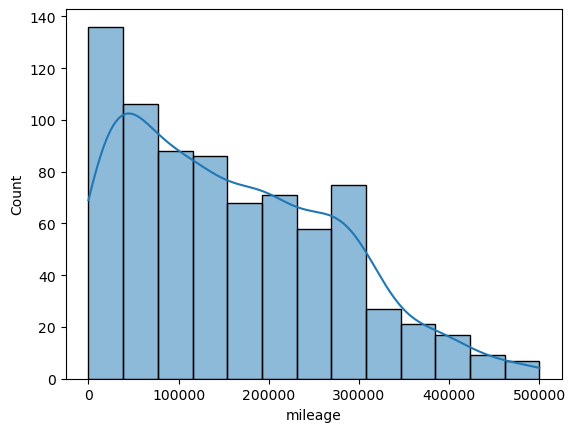

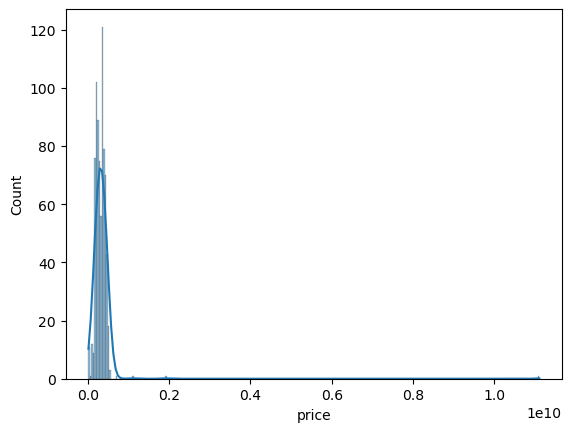

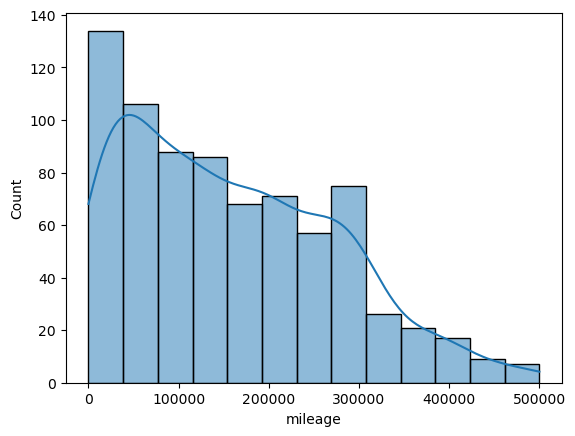

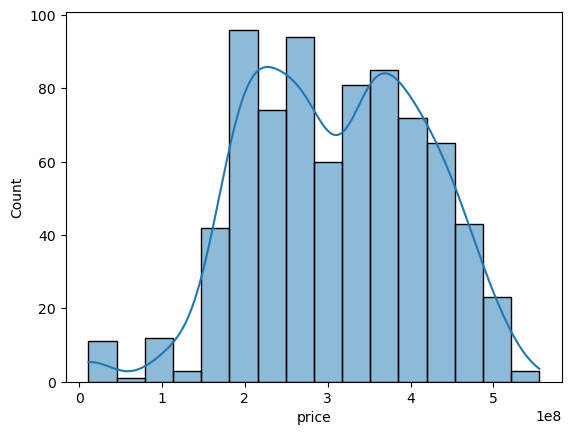

,year,mileage,color,fuel_type,engine_condition,chassis_condition,body_condition,insurance,gearbox,price
769,۱۳۹۰,250000,سفید,بنزینی,سالم,سالم و پلمپ,خط و خش جزیی,۷ ماه,دنده‌ای,280000000
368,۱۴۰۲,1200,مشکی,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۱۲ ماه,دنده‌ای,320000000
432,۱۳۹۸,118000,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۱۲ ماه,دنده‌ای,111111111
21,۱۳۸۴,204000,خاکستری,بنزینی,سالم,سالم و پلمپ,رنگ‌شدگی,۶ ماه,دنده‌ای,219000000
615,۱۳۸۵,332000,بژ,بنزینی,سالم,سالم و پلمپ,دوررنگ,۲ ماه,دنده‌ای,195000000
78,۱۳۸۹,270000,نوک‌مدادی,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۹ ماه,دنده‌ای,269000000
280,۱۳۹۸,38900,سفید,بنزینی,سالم,سالم و پلمپ,رنگ‌شدگی,۵ ماه,دنده‌ای,350000000
382,۱۴۰۱,0,سفید,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۱۲ ماه,دنده‌ای,500000000
722,۱۳۸۶,468000,نقره‌ای,بنزینی,سالم,سالم و پلمپ,دوررنگ,۱۲ ماه,دنده‌ای,175000000
337,۱۳۹۵,130000,آبی,بنزینی,سالم,سالم و پلمپ,سالم و بی‌خط و خش,۱ ماه,دنده‌ای,365000000


the number of samples: 765


['ordinal_encoder.pkl']

['scaler.pkl']

RandomForestRegressor(max_depth=50, max_features='sqrt', min_samples_split=10,
                      n_estimators=500, random_state=42)

In [4]:
#____________________________ part 3 ______________________________#
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns 
import matplotlib.pyplot as plt 
import joblib

data = pd.read_csv('peugeot_206_type2_price.csv', sep=',')
data = data.drop('Unnamed: 0', axis=1)
data.sample(10)
print(f"the number of samples: {len(data)}")

# Define a dictionary to map Persian numbers to English numbers
persian_to_english = {
    '۰': '0',
    '۱': '1',
    '۲': '2',
    '۳': '3',
    '۴': '4',
    '۵': '5',
    '۶': '6',
    '۷': '7',
    '۸': '8',
    '۹': '9',
    '٬': '',
    ' تومان': ''
}

# Replace Persian numbers with English numbers in the mileage column
data['mileage'] = data['mileage'].str.replace(r'[۰-۹٬]', lambda m: persian_to_english[m.group()], regex=True)

# Remove the word 'تومان' from the price column
data['price'] = data['price'].str.replace(' تومان', '')
# Replace Persian numbers with English numbers in the price column
data['price'] = data['price'].str.replace(r'[۰-۹٬]', lambda m: persian_to_english[m.group()], regex=True)
#data.tail()

# Set the display option to show all rows
pd.set_option('display.max_rows', None)

print(data['price'].value_counts())
print(data['mileage'].value_counts())

# Remove rows where the price is 'توافقی'
data = data[data['price'] != 'توافقی']

data['mileage'] = data['mileage'].astype('int')
data['price'] = data['price'].astype('int')

_=sns.histplot(data['mileage'],kde=True)
_=plt.figure()
_=sns.histplot(data['price'],kde=True)

def delete_outlier(df,attr):
    Q1=df[attr].quantile(0.25)
    Q3=df[attr].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]

data=delete_outlier(data,'mileage')
data=delete_outlier(data,'price')

_=plt.figure()
_=sns.histplot(data['mileage'],kde=True)
_=plt.figure()
_=sns.histplot(data['price'],kde=True)
plt.show()

# Fill NaN values in 'price' and 'mileage' columns with their respective column averages
data['price'].fillna(data['price'].mean(), inplace=True)
data['mileage'].fillna(data['mileage'].mean(), inplace=True)

# Drop rows with NaN values in 'year' and 'color' columns
data.dropna(subset=['year', 'color'], inplace=True)

# Fill NaN values in remaining columns with their respective column modes (most frequent value)
for column in data.columns:
    if column not in ['year', 'color']:
        data[column].fillna(data[column].mode()[0], inplace=True)

data.sample(10)
print(f"the number of samples: {len(data)}")

# Select the non-numeric features
non_numeric_features = list(data.columns)
non_numeric_features.remove('mileage')
non_numeric_features.remove('price')

# Create a subset of the DataFrame with only the non-numeric features
data_non_numeric = data[non_numeric_features]

# Initialize the OrdinalEncoder
encoder = OrdinalEncoder()

# Fit and transform the non-numeric features
data_non_numeric_encoded = encoder.fit_transform(data_non_numeric)

# Save the OrdinalEncoder
joblib.dump(encoder, 'ordinal_encoder.pkl')

# Replace the non-numeric features in the original DataFrame with the encoded values
data[non_numeric_features] = data_non_numeric_encoded

# Create a subset of the DataFrame with all features except 'price'
features_to_scale = data.drop('price', axis=1)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features to be scaled
scaled_features = scaler.fit_transform(features_to_scale)

# Save the StandardScaler
joblib.dump(scaler, 'scaler.pkl')

# Replace the scaled features in the original DataFrame
data[features_to_scale.columns] = scaled_features

X = data.drop('price', axis=1)  # Features
y = data['price']  # Target variable

# Split the data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# Model Training
rf = RandomForestRegressor(n_estimators=500, max_depth=50, min_samples_split=10, min_samples_leaf=1, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)


In [5]:
#____________________________ part 4 ______________________________#

# Model Evaluation on Validation Set
y_val_pred = rf.predict(X_val)
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)
print("Validation Set - MSE: {:.2f}, R-squared: {:.2f}".format(mse, r2))

# Final Model Evaluation on Test Set
y_test_pred = rf.predict(X_test)
mse_final = mean_squared_error(y_test, y_test_pred)
r2_final = r2_score(y_test, y_test_pred)
print("Test Set - MSE: {:.2f}, R-squared: {:.2f}".format(mse_final, r2_final))


Validation Set - MSE: 1917631901669672.25, R-squared: 0.79
Test Set - MSE: 2141724032206188.00, R-squared: 0.78


In [6]:
#____________________________ part 5 ______________________________#

# Save the trained model
joblib.dump(rf, 'random_forest_model.pkl')

# Load the trained model
rf = joblib.load('random_forest_model.pkl')

# Define the feature names
feature_names = ['year', 'mileage', 'color', 'fuel_type', 'engine_condition', 
                'chassis_condition', 'body_condition', 'insurance', 'gearbox', 'price']

# Create an empty DataFrame with the feature names
new_sample = pd.DataFrame(columns=feature_names)

year = input("Enter the year of production: ")
mileage = input("Enter the mileage in kilometer: ")
color = input("Enter the color: ")
fuel_type = input("Enter the fuel type: ")
engine_condition = input("Enter the engine condition: ")
chassis_condition = input("Enter the chassis condition: ")
body_condition = input("Enter the body condition: ")
insurance = input("Enter the remaining insurance validity: ")
gearbox = input("Enter the type of gearbox: ")
price = input("Enter the price: ")

# Define the values for the first row
values = [year, mileage, color, fuel_type, engine_condition, chassis_condition,
        body_condition, insurance, gearbox, price]

# Add the first row to the DataFrame
new_sample.loc[0] = values

# Function to predict price reasonableness
def predict_price(car_info):

    data = car_info

    # Define a dictionary to map Persian numbers to English numbers
    persian_to_english = {
        '۰': '0',
        '۱': '1',
        '۲': '2',
        '۳': '3',
        '۴': '4',
        '۵': '5',
        '۶': '6',
        '۷': '7',
        '۸': '8',
        '۹': '9',
        '٬': '',
        ' تومان': ''
    }

    # Replace Persian numbers with English numbers in the mileage column
    data['mileage'] = data['mileage'].str.replace(r'[۰-۹٬]', lambda m: persian_to_english[m.group()], regex=True)

    # Remove the word 'تومان' from the price column
    data['price'] = data['price'].str.replace(' تومان', '')
    # Replace Persian numbers with English numbers in the price column
    data['price'] = data['price'].str.replace(r'[۰-۹٬]', lambda m: persian_to_english[m.group()], regex=True)
    
    data['mileage'] = data['mileage'].astype('int')
    data['price'] = data['price'].astype('int')

    # Select the non-numeric features
    non_numeric_features = list(data.columns)
    non_numeric_features.remove('mileage')
    non_numeric_features.remove('price')

    # Create a subset of the DataFrame with only the non-numeric features
    data_non_numeric = data[non_numeric_features]

    encoder = joblib.load('ordinal_encoder.pkl')

    # Convert categorical features using the loaded ordinal encoder
    data_non_numeric_encoded = encoder.transform(data_non_numeric)

    # Replace the non-numeric features in the original DataFrame with the encoded values
    data[non_numeric_features] = data_non_numeric_encoded

    # Create a subset of the DataFrame with all features except 'price'
    features_to_scale = data.drop('price', axis=1)

    scaler = joblib.load('scaler.pkl')

    # Scale the features using the loaded scaler
    scaled_features = scaler.transform(features_to_scale)

    # Replace the scaled features in the original DataFrame
    data[features_to_scale.columns] = scaled_features

    X = data.drop('price', axis=1)  # Features
    y = data['price']  # Target variable

    # Make price prediction using the loaded model
    predicted_price = rf.predict(X)

    # Determine the reasonableness of the price
    user_price = data.iloc[0]["price"]  # Get user input for price
    if user_price < 0.8 * predicted_price:
        return "Cheap"
    elif user_price > 1.2 * predicted_price:
        return "Expensive"
    else:
        return "Reasonable"

prediction = predict_price(new_sample)
print(f"suggested price is {prediction}")


['random_forest_model.pkl']